# GridEdge: NFL Receiver Start/Sit Projection Model

This project builds a fantasy football start/sit model for NFL receivers. The model uses recent target volume, recent fantasy production, season averages, and volatility to predict PPR fantasy points. It compares the model against a simple baseline projection and then recommends which player to start.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install nflreadpy pandas scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import nflreadpy as nfl

pd.set_option("display.max_columns", None)

print("Setup works")

Setup works


In [4]:
pbp = nfl.load_pbp([2021, 2022, 2023, 2024])

# Convert to pandas if needed
if hasattr(pbp, "to_pandas"):
    pbp = pbp.to_pandas()

print(pbp.shape)
pbp.head()

(198513, 372)


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,run_location,run_gap,field_goal_result,kick_distance,extra_point_result,two_point_conv_result,home_timeouts_remaining,away_timeouts_remaining,timeout,timeout_team,td_team,td_player_name,td_player_id,posteam_timeouts_remaining,defteam_timeouts_remaining,total_home_score,total_away_score,posteam_score,defteam_score,score_differential,posteam_score_post,defteam_score_post,score_differential_post,no_score_prob,opp_fg_prob,opp_safety_prob,opp_td_prob,fg_prob,safety_prob,td_prob,extra_point_prob,two_point_conversion_prob,ep,epa,total_home_epa,total_away_epa,total_home_rush_epa,total_away_rush_epa,total_home_pass_epa,total_away_pass_epa,air_epa,yac_epa,comp_air_epa,comp_yac_epa,total_home_comp_air_epa,total_away_comp_air_epa,total_home_comp_yac_epa,total_away_comp_yac_epa,total_home_raw_air_epa,total_away_raw_air_epa,total_home_raw_yac_epa,total_away_raw_yac_epa,wp,def_wp,home_wp,away_wp,wpa,vegas_wpa,vegas_home_wpa,home_wp_post,away_wp_post,vegas_wp,vegas_home_wp,total_home_rush_wpa,total_away_rush_wpa,total_home_pass_wpa,total_away_pass_wpa,air_wpa,yac_wpa,comp_air_wpa,comp_yac_wpa,total_home_comp_air_wpa,total_away_comp_air_wpa,total_home_comp_yac_wpa,total_away_comp_yac_wpa,total_home_raw_air_wpa,total_away_raw_air_wpa,total_home_raw_yac_wpa,total_away_raw_yac_wpa,punt_blocked,first_down_rush,first_down_pass,first_down_penalty,third_down_converted,third_down_failed,fourth_down_converted,fourth_down_failed,incomplete_pass,touchback,interception,punt_inside_twenty,punt_in_endzone,punt_out_of_bounds,punt_downed,punt_fair_catch,kickoff_inside_twenty,kickoff_in_endzone,kickoff_out_of_bounds,kickoff_downed,kickoff_fair_catch,fumble_forced,fumble_not_forced,fumble_out_of_bounds,solo_tackle,safety,penalty,tackled_for_loss,fumble_lost,own_kickoff_recovery,own_kickoff_recovery_td,qb_hit,rush_attempt,pass_attempt,sack,touchdown,pass_touchdown,rush_touchdown,return_touchdown,extra_point_attempt,two_point_attempt,field_goal_attempt,kickoff_attempt,punt_attempt,fumble,complete_pass,assist_tackle,lateral_reception,lateral_rush,lateral_return,lateral_recovery,passer_player_id,passer_player_name,passing_yards,receiver_player_id,receiver_player_name,receiving_yards,rusher_player_id,rusher_player_name,rushing_yards,lateral_receiver_player_id,lateral_receiver_player_name,lateral_receiving_yards,lateral_rusher_player_id,lateral_rusher_player_name,lateral_rushing_yards,lateral_sack_player_id,lateral_sack_player_name,interception_player_id,interception_player_name,lateral_interception_player_id,lateral_interception_player_name,punt_returner_player_id,punt_returner_player_name,lateral_punt_returner_player_id,lateral_punt_returner_player_name,kickoff_returner_player_name,kickoff_returner_player_id,lateral_kickoff_returner_player_id,lateral_kickoff_returner_player_name,punter_player_id,punter_player_name,kicker_player_name,kicker_player_id,own_kickoff_recovery_player_id,own_kickoff_recovery_player_name,blocked_player_id,blocked_player_name,tackle_for_loss_1_player_id,tackle_for_loss_1_player_name,tackle_for_loss_2_player_id,tackle_for_loss_2_player_name,qb_hit_1_player_id,qb_hit_1_player_name,qb_hit_2_player_id,qb_hit_2_player_name,forced_fumble_player_1_team,forced_fumble_player_1_player_id,forced_fumble_player_1_player_name,forced_fumble_player_2_team,forced_fumble_player_2_player_id,forced_fumble_player_2_player_name,solo_tackle_1_team,solo_tackle_2_team,solo_tackle_1_player_id,solo_tackle_2_player_id,solo_tackle_1_player_name,solo_tackle_2_player_name,assist_tackle_1_player_id,assist_tackle_1_player_name,assist_tackle_1_team,assist_tack

In [5]:
for col in pbp.columns:
    print(col)

play_id
game_id
old_game_id
home_team
away_team
season_type
week
posteam
posteam_type
defteam
side_of_field
yardline_100
game_date
quarter_seconds_remaining
half_seconds_remaining
game_seconds_remaining
game_half
quarter_end
drive
sp
qtr
down
goal_to_go
time
yrdln
ydstogo
ydsnet
desc
play_type
yards_gained
shotgun
no_huddle
qb_dropback
qb_kneel
qb_spike
qb_scramble
pass_length
pass_location
air_yards
yards_after_catch
run_location
run_gap
field_goal_result
kick_distance
extra_point_result
two_point_conv_result
home_timeouts_remaining
away_timeouts_remaining
timeout
timeout_team
td_team
td_player_name
td_player_id
posteam_timeouts_remaining
defteam_timeouts_remaining
total_home_score
total_away_score
posteam_score
defteam_score
score_differential
posteam_score_post
defteam_score_post
score_differential_post
no_score_prob
opp_fg_prob
opp_safety_prob
opp_td_prob
fg_prob
safety_prob
td_prob
extra_point_prob
two_point_conversion_prob
ep
epa
total_home_epa
total_away_epa
total_home_rush_epa


In [6]:
needed_cols = [
    "season",
    "week",
    "receiver_player_id",
    "receiver_player_name",
    "posteam",
    "defteam",
    "complete_pass",
    "yards_gained",
    "touchdown",
    "air_yards",
    "yardline_100"
]

missing_cols = [col for col in needed_cols if col not in pbp.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All needed columns exist")

All needed columns exist


In [7]:
# Keep only pass plays where a receiver is listed
receiving = pbp[pbp["receiver_player_name"].notna()].copy()

# Create basic receiving stats per play
receiving["target"] = 1
receiving["reception"] = receiving["complete_pass"].fillna(0)
receiving["receiving_yards"] = receiving["yards_gained"].fillna(0)
receiving["receiving_td"] = receiving["touchdown"].fillna(0)
receiving["air_yards"] = receiving["air_yards"].fillna(0)
receiving["red_zone_target"] = (receiving["yardline_100"] <= 20).astype(int)

# Group by player-game
wr_games = (
    receiving
    .groupby([
        "season",
        "week",
        "receiver_player_id",
        "receiver_player_name",
        "posteam",
        "defteam"
    ], as_index=False)
    .agg({
        "target": "sum",
        "reception": "sum",
        "receiving_yards": "sum",
        "receiving_td": "sum" ,
        "air_yards": "sum",
        "red_zone_target": "sum"
    })
)

# Calculate PPR fantasy points
wr_games["ppr_points"] = (
    wr_games["reception"] * 1 +
    wr_games["receiving_yards"] * 0.1 +
    wr_games["receiving_td"] * 6
)

wr_games["adot"] = wr_games["air_yards"] / wr_games["target"].replace(0, 1)
wr_games["red_zone_target_share"] = wr_games["red_zone_target"] / wr_games["target"].replace(0, 1)

print(wr_games.shape)
wr_games.head(20)

(18230, 15)


,season,week,receiver_player_id,receiver_player_name,posteam,defteam,target,reception,receiving_yards,receiving_td,air_yards,red_zone_target,ppr_points,adot,red_zone_target_share
0,2021,1,00-0024243,M.Lewis,GB,NO,1,1.0,19.0,0.0,5.0,0,2.9,5.000000,0.000000
1,2021,1,00-0026035,D.Amendola,HOU,JAX,5,5.0,34.0,1.0,20.0,1,14.4,4.000000,0.200000
2,2021,1,00-0026189,D.Jackson,LA,CHI,2,2.0,21.0,0.0,16.0,0,4.1,8.000000,0.000000
3,2021,1,00-0027061,J.Cook,LAC,WAS,8,5.0,56.0,0.0,67.0,2,10.6,8.375000,0.250000
4,2021,1,00-0027656,R.Gronkowski,TB,DAL,8,8.0,90.0,2.0,53.0,2,29.0,6.625000,0.250000
5,2021,1,00-0027685,E.Sanders,BUF,PIT,8,4.0,52.0,0.0,149.0,0,9.2,18.625000,0.000000
6,2021,1,00-0027696,J.Graham,CHI,LA,2,1.0,11.0,0.0,12.0,1,2.1,6.000000,0.500000
7,2021,1,00-0027793,A.Brown,TB,DAL,7,5.0,121.0,1.0,144.0,0,23.1,20.571429,0.000000
8,2021,1,00-0027942,A.Green,ARI,TEN,6,2.0,25.0,0.0,53.0,1,4.5,8.833333,0.166667
9,2021,1,00-0027944,J.Jones,TEN,ARI,6,3.0,29.0,0.0,66.0,1,5.9,11.000000,0.166667


### Add Team Passing/Target Volume and Player Opportunity Share

In [8]:
team_game_volume = (
    wr_games
    .groupby(["season", "week", "posteam"], as_index=False)
    .agg({
        "target": "sum",
        "reception": "sum",
        "receiving_yards": "sum",
        "ppr_points": "sum"
    })
    .rename(columns={
        "target": "team_targets",
        "reception": "team_receptions",
        "receiving_yards": "team_receiving_yards",
        "ppr_points": "team_receiving_ppr"
    })
)

wr_games = wr_games.merge(
    team_game_volume,
    on=["season", "week", "posteam"],
    how="left"
)

# Player opportunity share
wr_games["target_share"] = wr_games["target"] / wr_games["team_targets"]
wr_games["reception_share"] = wr_games["reception"] / wr_games["team_receptions"]
wr_games["yard_share"] = wr_games["receiving_yards"] / wr_games["team_receiving_yards"]

# Clean possible divide-by-zero issues
wr_games[["target_share", "reception_share", "yard_share"]] = (
    wr_games[["target_share", "reception_share", "yard_share"]]
    .replace([float("inf"), -float("inf")], 0)
    .fillna(0)
)

print(wr_games.shape)
wr_games.head()

(18230, 22)


,season,week,receiver_player_id,receiver_player_name,posteam,defteam,target,reception,receiving_yards,receiving_td,air_yards,red_zone_target,ppr_points,adot,red_zone_target_share,team_targets,team_receptions,team_receiving_yards,team_receiving_ppr,target_share,reception_share,yard_share
0,2021,1,00-0024243,M.Lewis,GB,NO,1,1.0,19.0,0.0,5.0,0,2.9,5.000,0.00,33,20.0,201.0,40.1,0.030303,0.050000,0.094527
1,2021,1,00-0026035,D.Amendola,HOU,JAX,5,5.0,34.0,1.0,20.0,1,14.4,4.000,0.20,32,21.0,291.0,62.1,0.156250,0.238095,0.116838
2,2021,1,00-0026189,D.Jackson,LA,CHI,2,2.0,21.0,0.0,16.0,0,4.1,8.000,0.00,26,20.0,321.0,70.1,0.076923,0.100000,0.065421
3,2021,1,00-0027061,J.Cook,LAC,WAS,8,5.0,56.0,0.0,67.0,2,10.6,8.375,0.25,46,31.0,337.0,70.7,0.173913,0.161290,0.166172
4,2021,1,00-0027656,R.Gronkowski,TB,DAL,8,8.0,90.0,2.0,53.0,2,29.0,6.625,0.25,45,32.0,379.0,93.9,0.177778,0.250000,0.237467


### Add Matchup Difficulty Features

In [9]:
# How many receiving fantasy points each defense allowed each week
defense_allowed = (
    wr_games
    .groupby(["season", "week", "defteam"], as_index=False)
    .agg({
        "ppr_points": "sum",
        "target": "sum",
        "receiving_yards": "sum",
        "receiving_td": "sum"
    })
    .rename(columns={
        "ppr_points": "def_allowed_receiving_ppr",
        "target": "def_allowed_targets",
        "receiving_yards": "def_allowed_receiving_yards",
        "receiving_td": "def_allowed_receiving_tds"
    })
)

defense_allowed = defense_allowed.sort_values(["defteam", "season", "week"])

# Rolling defensive averages BEFORE each game
defense_allowed["def_allowed_ppr_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_ppr"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_targets_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_targets"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_yards_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_yards"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_tds_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_tds"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Keep only the shifted matchup features
defense_features = defense_allowed[[
    "season",
    "week",
    "defteam",
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5",
    "def_allowed_yards_last_5",
    "def_allowed_tds_last_5"
]]

wr_games = wr_games.merge(
    defense_features,
    on=["season", "week", "defteam"],
    how="left"
)

wr_games[[
    "receiver_player_name",
    "season",
    "week",
    "defteam",
    "ppr_points",
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5"
]].head()

,receiver_player_name,season,week,defteam,ppr_points,def_allowed_ppr_last_5,def_allowed_targets_last_5
0,M.Lewis,2021,1,NO,2.9,NaN,NaN
1,D.Amendola,2021,1,JAX,14.4,NaN,NaN
2,D.Jackson,2021,1,CHI,4.1,NaN,NaN
3,J.Cook,2021,1,WAS,10.6,NaN,NaN
4,R.Gronkowski,2021,1,DAL,29.0,NaN,NaN


In [10]:
wr_games = wr_games.sort_values(
    by=["receiver_player_name", "season", "week"]
).reset_index(drop=True)

wr_games.sort_values("ppr_points", ascending=False).head(20)

,season,week,receiver_player_id,receiver_player_name,posteam,defteam,target,reception,receiving_yards,receiving_td,air_yards,red_zone_target,ppr_points,adot,red_zone_target_share,team_targets,team_receptions,team_receiving_yards,team_receiving_ppr,target_share,reception_share,yard_share,def_allowed_ppr_last_5,def_allowed_targets_last_5,def_allowed_yards_last_5,def_allowed_tds_last_5
7888,2021,17,00-0036900,J.Chase,CIN,KC,12,11.0,266.0,3.0,146.0,2,55.6,12.166667,0.166667,38,30.0,446.0,98.6,0.315789,0.366667,0.596413,57.120000,40.200000,233.2,1.200000
7934,2024,10,00-0036900,J.Chase,CIN,BAL,17,11.0,264.0,3.0,243.0,2,55.4,14.294118,0.117647,55,34.0,428.0,100.8,0.309091,0.323529,0.616822,75.040000,38.600000,318.4,2.800000
7913,2023,5,00-0036900,J.Chase,CIN,ARI,19,15.0,192.0,3.0,154.0,5,52.2,8.105263,0.263158,44,36.0,317.0,85.7,0.431818,0.416667,0.605678,55.260000,28.400000,246.6,1.600000
6735,2021,20,00-0036196,G.Davis,BUF,KC,10,8.0,201.0,4.0,199.0,2,52.1,19.900000,0.200000,38,27.0,331.0,84.1,0.263158,0.296296,0.607251,60.580000,37.000000,253.8,1.800000
230,2023,16,00-0031544,A.Cooper,CLE,HOU,16,11.0,267.0,2.0,286.0,5,49.7,17.875000,0.312500,44,28.0,376.0,83.6,0.363636,0.392857,0.710106,51.720000,30.400000,253.2,1.000000
5085,2023,5,00-0034827,D.Moore,CHI,WAS,10,8.0,230.0,3.0,115.0,2,49.0,11.500000,0.200000,25,15.0,282.0,67.2,0.400000,0.533333,0.815603,51.300000,32.000000,221.0,1.600000
12243,2022,17,00-0031408,M.Evans,TB,CAR,12,10.0,207.0,3.0,220.0,1,48.7,18.333333,0.083333,44,34.0,434.0,95.4,0.272727,0.294118,0.476959,52.580000,32.400000,229.8,1.400000
16420,2021,4,00-0033040,T.Hill,KC,PHI,12,11.0,186.0,3.0,163.0,2,47.6,13.583333,0.166667,30,24.0,278.0,81.8,0.400000,0.458333,0.669065,49.033333,29.333333,197.0,1.333333
8779,2024,3,00-0036259,J.Jennings,SF,LA,12,11.0,175.0,3.0,149.0,2,46.5,12.416667,0.166667,30,22.0,292.0,69.2,0.400000,0.500000,0.599315,53.760000,28.000000,253.6,1.400000
15435,2022,2,00-0031588,S.Diggs,BUF,TEN,15,12.0,148.0,3.0,141.0,4,44.8,9.400000,0.266667,39,26.0,317.0,81.7,0.384615,0.461538,0.466877,56.960000,32.600000,273.6,1.200000


In [11]:
wr_games["last_3_targets"] = (
    wr_games
    .groupby("receiver_player_id")["target"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

wr_games["last_3_receptions"] = (
    wr_games
    .groupby("receiver_player_id")["reception"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

wr_games["last_3_yards"] = (
    wr_games
    .groupby("receiver_player_id")["receiving_yards"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

wr_games["last_3_ppr"] = (
    wr_games
    .groupby("receiver_player_id")["ppr_points"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

wr_games["last_5_targets"] = (
    wr_games
    .groupby("receiver_player_id")["target"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_5_receptions"] = (
    wr_games
    .groupby("receiver_player_id")["reception"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_5_yards"] = (
    wr_games
    .groupby("receiver_player_id")["receiving_yards"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_5_ppr"] = (
    wr_games
    .groupby("receiver_player_id")["ppr_points"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_3_target_share"] = (
    wr_games
    .groupby("receiver_player_id")["target_share"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

wr_games["last_5_target_share"] = (
    wr_games
    .groupby("receiver_player_id")["target_share"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_8_targets"] = (
    wr_games
    .groupby("receiver_player_id")["target"]
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

wr_games["last_8_ppr"] = (
    wr_games
    .groupby("receiver_player_id")["ppr_points"]
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

wr_games["last_8_target_share"] = (
    wr_games
    .groupby("receiver_player_id")["target_share"]
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

wr_games[[
    "receiver_player_name",
    "season",
    "week",
    "target",
    "reception",
    "receiving_yards",
    "ppr_points",
    "last_3_targets",
    "last_3_ppr",
    "last_3_target_share",
    "last_8_ppr"
]].head(30)

,receiver_player_name,season,week,target,reception,receiving_yards,ppr_points,last_3_targets,last_3_ppr,last_3_target_share,last_8_ppr
0,A.Abdullah,2021,1,2,2.0,15.0,3.5,NaN,NaN,NaN,NaN
1,A.Abdullah,2021,2,1,0.0,0.0,0.0,2.000000,3.500000,0.042553,3.500000
2,A.Abdullah,2021,4,1,1.0,2.0,1.2,1.500000,1.750000,0.036902,1.750000
3,A.Abdullah,2021,8,5,3.0,35.0,6.5,1.333333,1.566667,0.033860,1.566667
4,A.Abdullah,2021,9,5,4.0,30.0,7.0,2.333333,2.566667,0.089120,2.800000
5,A.Abdullah,2021,10,4,4.0,27.0,6.7,3.666667,4.900000,0.136175,3.640000
6,A.Abdullah,2021,12,6,2.0,20.0,4.0,4.666667,6.733333,0.167320,4.150000
7,A.Abdullah,2021,14,4,2.0,17.0,9.7,5.000000,5.900000,0.162391,4.128571
8,A.Abdullah,2021,15,4,4.0,48.0,14.8,4.666667,6.800000,0.143015,4.825000
9,A.Abdullah,2021,16,6,3.0,8.0,3.8,4.666667,9.500000,0.138647,6.237500


In [12]:
wr_games["last_5_adot"] = (
    wr_games
    .groupby("receiver_player_id")["adot"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

wr_games["last_5_red_zone_share"] = (
    wr_games
    .groupby("receiver_player_id")["red_zone_target_share"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [13]:
wr_games["season_avg_targets"] = (
    wr_games
    .groupby(["receiver_player_id", "season"])["target"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

wr_games["season_avg_receptions"] = (
    wr_games
    .groupby(["receiver_player_id", "season"])["reception"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

wr_games["season_avg_yards"] = (
    wr_games
    .groupby(["receiver_player_id", "season"])["receiving_yards"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

wr_games["season_avg_ppr"] = (
    wr_games
    .groupby(["receiver_player_id", "season"])["ppr_points"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

wr_games.head(20)

,season,week,receiver_player_id,receiver_player_name,posteam,defteam,target,reception,receiving_yards,receiving_td,air_yards,red_zone_target,ppr_points,adot,red_zone_target_share,team_targets,team_receptions,team_receiving_yards,team_receiving_ppr,target_share,reception_share,yard_share,def_allowed_ppr_last_5,def_allowed_targets_last_5,def_allowed_yards_last_5,def_allowed_tds_last_5,last_3_targets,last_3_receptions,last_3_yards,last_3_ppr,last_5_targets,last_5_receptions,last_5_yards,last_5_ppr,last_3_target_share,last_5_target_share,last_8_targets,last_8_ppr,last_8_target_share,last_5_adot,last_5_red_zone_share,season_avg_targets,season_avg_receptions,season_avg_yards,season_avg_ppr
0,2021,1,00-0032104,A.Abdullah,MIN,CIN,2,2.0,15.0,0.0,2.0,0,3.5,1.000000,0.000000,47,37.0,362.0,85.2,0.042553,0.054054,0.041436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,2,00-0032104,A.Abdullah,MIN,ARI,1,0.0,0.0,0.0,4.0,0,0.0,4.000000,0.000000,32,22.0,244.0,64.4,0.031250,0.000000,0.000000,49.800000,36.000000,218.000000,1.000000,2.000000,2.000000,15.000000,3.500000,2.000000,2.0,15.000000,3.500000,0.042553,0.042553,2.000000,3.500000,0.042553,1.000000,0.000000,2.000000,2.000000,15.000000,3.500000
2,2021,4,00-0032104,A.Abdullah,MIN,CLE,1,1.0,2.0,0.0,-4.0,0,1.2,-4.000000,0.000000,36,20.0,203.0,46.3,0.027778,0.050000,0.009852,48.066667,27.666667,210.666667,1.666667,1.500000,1.000000,7.500000,1.750000,1.500000,1.0,7.500000,1.750000,0.036902,0.036902,1.500000,1.750000,0.036902,2.500000,0.000000,1.500000,1.000000,7.500000,1.750000
3,2021,8,00-0032104,A.Abdullah,CAR,ATL,5,3.0,35.0,0.0,7.0,1,6.5,1.400000,0.200000,24,13.0,129.0,25.9,0.208333,0.230769,0.271318,65.140000,35.200000,263.400000,2.400000,1.333333,1.000000,5.666667,1.566667,1.333333,1.0,5.666667,1.566667,0.033860,0.033860,1.333333,1.566667,0.033860,0.333333,0.000000,1.333333,1.000000,5.666667,1.566667
4,2021,9,00-0032104,A.Abdullah,CAR,NE,5,4.0,30.0,0.0,13.0,0,7.0,2.600000,0.000000,29,16.0,172.0,39.2,0.172414,0.250000,0.174419,66.640000,39.000000,300.400000,2.000000,2.333333,1.333333,12.333333,2.566667,2.250000,1.5,13.000000,2.800000,0.089120,0.077479,2.250000,2.800000,0.077479,0.600000,0.050000,2.250000,1.500000,13.000000,2.800000
5,2021,10,00-0032104,A.Abdullah,CAR,ARI,4,4.0,27.0,0.0,-5.0,0,6.7,-1.250000,0.000000,33,25.0,177.0,48.7,0.121212,0.160000,0.152542,50.340000,32.800000,215.400000,1.200000,3.666667,2.666667,22.333333,4.900000,2.800000,2.0,16.400000,3.640000,0.136175,0.096466,2.800000,3.640000,0.096466,1.000000,0.040000,2.800000,2.000000,16.400000,3.640000
6,2021,12,00-0032104,A.Abdullah,CAR,MIA,6,2.0,20.0,0.0,6.0,0,4.0,1.000000,0.000000,31,10.0,179.0,27.9,0.193548,0.200000,0.111732,62.280000,39.200000,270.800000,1.600000,4.666667,3.666667,30.666667,6.733333,3.200000,2.4,18.800000,4.280000,0.167320,0.112197,3.000000,4.150000,0.100590,0.550000,0.040000,3.000000,2.333333,18.166667,4.150000
7,2021,14,00-0032104,A.Abdullah,CAR,ATL,4,2.0,17.0,1.0,-1.0,1,9.7,-0.250000,0.250000,35,21.0,253.0,58.3,0.114286,0.095238,0.067194,68.880000,39.000000,280.800000,2.200000,5.000000,3.333333,25.666667,5.900000,4.200000,2.8,22.800000,5.080000,0.162391,0.144657,3.428571,4.128571,0.113870,-0.050000,0.040000,3.428571,2.285714,18.428571,4.128571
8,2021,15,00-0032104,A.Abdullah,CAR,BUF,4,4.0,48.0,1.0,17.0,0,14.8,4.250000,0.000000,37,18.0,158.0,39.8,0.108108,0.222222,0.303797,42.580000,28.800000,189.800000,1.000000,4.666667,2.666667,21.333333,6.800000,4.800000,3.0,25.800000,6.780000,0.143015,0.161959,3.500000,4.825000,0.113922,0.700000,0.090000,3.500000,2.250000,18.250000,4.825000
9,2021,16,00-0032104,A.Abdullah,CAR,TB,6,3.0,8.0,0.0,25.0,2,3.8,4.166667,0.333333,43,22.0,251.0,47.1,0.139535,0.136364,0.031873,57.640000,39.200000,246.400000,1.200000,4.666667,2.666667,28.333333,9.500000,4.600000,3.2,28.400000,8.440000,0.138647,0.141914,3.750000,6.237500,0.122116,1.270000,0.050000,3.555556,2.444444,21.555556,5.933333


In [14]:
wr_games["last_3_ppr_std"] = (
    wr_games
    .groupby("receiver_player_id")["ppr_points"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
)

# Fill missing volatility with 0
wr_games["last_3_ppr_std"] = wr_games["last_3_ppr_std"].fillna(0)

wr_games[[
    "receiver_player_name",
    "season",
    "week",
    "ppr_points",
    "last_3_ppr",
    "last_3_ppr_std"
]].head(20)

,receiver_player_name,season,week,ppr_points,last_3_ppr,last_3_ppr_std
0,A.Abdullah,2021,1,3.5,NaN,0.000000
1,A.Abdullah,2021,2,0.0,3.500000,0.000000
2,A.Abdullah,2021,4,1.2,1.750000,2.474874
3,A.Abdullah,2021,8,6.5,1.566667,1.778576
4,A.Abdullah,2021,9,7.0,2.566667,3.458805
5,A.Abdullah,2021,10,6.7,4.900000,3.214032
6,A.Abdullah,2021,12,4.0,6.733333,0.251661
7,A.Abdullah,2021,14,9.7,5.900000,1.652271
8,A.Abdullah,2021,15,14.8,6.800000,2.851315
9,A.Abdullah,2021,16,3.8,9.500000,5.402777


In [15]:
features = [
    # recent player volume
    "last_3_targets",
    "last_3_receptions",
    "last_3_yards",
    "last_3_ppr",
    "last_3_ppr_std",

    # longer player trends
    "last_5_targets",
    "last_5_receptions",
    "last_5_yards",
    "last_5_ppr",
    "last_5_target_share",
    "last_8_targets",
    "last_8_ppr",
    "last_8_target_share",
    "last_5_adot",
    "last_5_red_zone_share",

    # season player averages
    "season_avg_targets",
    "season_avg_receptions",
    "season_avg_yards",
    "season_avg_ppr",

    # matchup
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5",
    "def_allowed_yards_last_5",
    "def_allowed_tds_last_5",

    # context
    "week"
]

target = "ppr_points"

In [16]:
model_data = wr_games.dropna(subset=features + [target]).copy()

# Optional: focus on fantasy-relevant players only
# This removes random backup players with 1 target.
model_data = model_data[
    (model_data["season_avg_targets"] >= 2) |
    (model_data["last_5_targets"] >= 2)
].copy()

print("Model rows:", model_data.shape[0])
model_data.head()

Model rows: 13827


,season,week,receiver_player_id,receiver_player_name,posteam,defteam,target,reception,receiving_yards,receiving_td,air_yards,red_zone_target,ppr_points,adot,red_zone_target_share,team_targets,team_receptions,team_receiving_yards,team_receiving_ppr,target_share,reception_share,yard_share,def_allowed_ppr_last_5,def_allowed_targets_last_5,def_allowed_yards_last_5,def_allowed_tds_last_5,last_3_targets,last_3_receptions,last_3_yards,last_3_ppr,last_5_targets,last_5_receptions,last_5_yards,last_5_ppr,last_3_target_share,last_5_target_share,last_8_targets,last_8_ppr,last_8_target_share,last_5_adot,last_5_red_zone_share,season_avg_targets,season_avg_receptions,season_avg_yards,season_avg_ppr,last_3_ppr_std
1,2021,2,00-0032104,A.Abdullah,MIN,ARI,1,0.0,0.0,0.0,4.0,0,0.0,4.00,0.00,32,22.0,244.0,64.4,0.031250,0.000000,0.000000,49.80,36.0,218.0,1.0,2.000000,2.000000,15.000000,3.500000,2.00,2.0,15.0,3.50,0.042553,0.042553,2.000000,3.500000,0.042553,1.00,0.00,2.000000,2.000000,15.000000,3.500000,0.000000
4,2021,9,00-0032104,A.Abdullah,CAR,NE,5,4.0,30.0,0.0,13.0,0,7.0,2.60,0.00,29,16.0,172.0,39.2,0.172414,0.250000,0.174419,66.64,39.0,300.4,2.0,2.333333,1.333333,12.333333,2.566667,2.25,1.5,13.0,2.80,0.089120,0.077479,2.250000,2.800000,0.077479,0.60,0.05,2.250000,1.500000,13.000000,2.800000,3.458805
5,2021,10,00-0032104,A.Abdullah,CAR,ARI,4,4.0,27.0,0.0,-5.0,0,6.7,-1.25,0.00,33,25.0,177.0,48.7,0.121212,0.160000,0.152542,50.34,32.8,215.4,1.2,3.666667,2.666667,22.333333,4.900000,2.80,2.0,16.4,3.64,0.136175,0.096466,2.800000,3.640000,0.096466,1.00,0.04,2.800000,2.000000,16.400000,3.640000,3.214032
6,2021,12,00-0032104,A.Abdullah,CAR,MIA,6,2.0,20.0,0.0,6.0,0,4.0,1.00,0.00,31,10.0,179.0,27.9,0.193548,0.200000,0.111732,62.28,39.2,270.8,1.6,4.666667,3.666667,30.666667,6.733333,3.20,2.4,18.8,4.28,0.167320,0.112197,3.000000,4.150000,0.100590,0.55,0.04,3.000000,2.333333,18.166667,4.150000,0.251661
7,2021,14,00-0032104,A.Abdullah,CAR,ATL,4,2.0,17.0,1.0,-1.0,1,9.7,-0.25,0.25,35,21.0,253.0,58.3,0.114286,0.095238,0.067194,68.88,39.0,280.8,2.2,5.000000,3.333333,25.666667,5.900000,4.20,2.8,22.8,5.08,0.162391,0.144657,3.428571,4.128571,0.113870,-0.05,0.04,3.428571,2.285714,18.428571,4.128571,1.652271


In [17]:
wr_games.to_csv('/content/drive/MyDrive/gridedge_wr_games_cache.csv', index=False)
print("Cached:", wr_games.shape)

Cached: (18230, 46)


### Add Matchup Difficulty Features

In [18]:
# How many receiving fantasy points each defense allowed each week
defense_allowed = (
    wr_games
    .groupby(["season", "week", "defteam"], as_index=False)
    .agg({
        "ppr_points": "sum",
        "target": "sum",
        "receiving_yards": "sum",
        "receiving_td": "sum"
    })
    .rename(columns={
        "ppr_points": "def_allowed_receiving_ppr",
        "target": "def_allowed_targets",
        "receiving_yards": "def_allowed_receiving_yards",
        "receiving_td": "def_allowed_receiving_tds"
    })
)

defense_allowed = defense_allowed.sort_values(["defteam", "season", "week"])

# Rolling defensive averages BEFORE each game
defense_allowed["def_allowed_ppr_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_ppr"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_targets_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_targets"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_yards_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_yards"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

defense_allowed["def_allowed_tds_last_5"] = (
    defense_allowed
    .groupby("defteam")["def_allowed_receiving_tds"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Keep only the shifted matchup features
defense_features = defense_allowed[[
    "season",
    "week",
    "defteam",
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5",
    "def_allowed_yards_last_5",
    "def_allowed_tds_last_5"
]]

# Before merging, check if the columns from defense_features already exist in wr_games
# and drop them to avoid suffixes from a redundant merge.
cols_to_drop = [col for col in defense_features.columns if col not in ["season", "week", "defteam"] and col in wr_games.columns]
if cols_to_drop:
    wr_games = wr_games.drop(columns=cols_to_drop)

wr_games = wr_games.merge(
    defense_features,
    on=["season", "week", "defteam"],
    how="left"
)

wr_games[[
    "receiver_player_name",
    "season",
    "week",
    "defteam",
    "ppr_points",
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5"
]].head()


,receiver_player_name,season,week,defteam,ppr_points,def_allowed_ppr_last_5,def_allowed_targets_last_5
0,A.Abdullah,2021,1,CIN,3.5,NaN,NaN
1,A.Abdullah,2021,2,ARI,0.0,49.800000,36.000000
2,A.Abdullah,2021,4,CLE,1.2,48.066667,27.666667
3,A.Abdullah,2021,8,ATL,6.5,65.140000,35.200000
4,A.Abdullah,2021,9,NE,7.0,66.640000,39.000000


In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train_data = model_data[model_data["season"].isin([2021, 2022, 2023])]
test_data = model_data[model_data["season"] == 2024]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

# Baseline
baseline_preds = X_test["season_avg_ppr"]
baseline_mae = mean_absolute_error(y_test, baseline_preds)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_preds)

# Ridge Regression
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_preds)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    min_samples_leaf=10,
    max_depth=8
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)

# Gradient Boosting
gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.03,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_preds)

model_scores = pd.DataFrame({
    "model": [
        "Baseline Season Average",
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        ridge_mae,
        rf_mae,
        gb_mae
    ]
}).sort_values("MAE")

model_scores

Train rows: 10409
Test rows: 3418


,model,MAE
3,Random Forest,4.449101
2,Ridge Regression,4.450953
1,Linear Regression,4.451476
4,Gradient Boosting,4.478973
0,Baseline Season Average,4.582491


In [20]:
baseline_preds = X_test["season_avg_ppr"]

baseline_mae = mean_absolute_error(y_test, baseline_preds)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 4.582490873864942


In [21]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_preds)

print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)
print("Improvement over baseline:", baseline_mae - linear_mae)

Baseline MAE: 4.582490873864942
Linear Regression MAE: 4.45147612709666
Improvement over baseline: 0.1310147467682823


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=5
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)

print("Baseline MAE:", baseline_mae)
print("Linear Regression MAE:", linear_mae)
print("Random Forest MAE:", rf_mae)
print("RF improvement over baseline:", baseline_mae - rf_mae)

Baseline MAE: 4.582490873864942
Linear Regression MAE: 4.45147612709666
Random Forest MAE: 4.505660078609818
RF improvement over baseline: 0.07683079525512415


In [23]:
test_rows = model_data.loc[X_test.index].copy()

test_rows["baseline_projection"] = baseline_preds
test_rows["linear_projection"] = linear_preds
test_rows["rf_projection"] = rf_preds

test_rows["baseline_error"] = abs(test_rows["ppr_points"] - test_rows["baseline_projection"])
test_rows["rf_error"] = abs(test_rows["ppr_points"] - test_rows["rf_projection"])

prediction_results = test_rows[[
    "receiver_player_name",
    "season",
    "week",
    "posteam",
    "defteam",
    "target",
    "reception",
    "receiving_yards",
    "receiving_td",
    "ppr_points",
    "baseline_projection",
    "rf_projection",
    "baseline_error",
    "rf_error"
]].copy()

prediction_results.head(25)

,receiver_player_name,season,week,posteam,defteam,target,reception,receiving_yards,receiving_td,ppr_points,baseline_projection,rf_projection,baseline_error,rf_error
42,A.Abdullah,2024,3,LV,CAR,2,2.0,13.0,0.0,3.3,2.100000,2.795275,1.200000,0.504725
43,A.Abdullah,2024,5,LV,DEN,3,3.0,9.0,0.0,3.9,2.700000,2.066919,1.200000,1.833081
44,A.Abdullah,2024,6,LV,PIT,5,3.0,14.0,0.0,4.4,3.100000,3.270664,1.300000,1.129336
45,A.Abdullah,2024,8,LV,KC,2,1.0,9.0,0.0,1.9,3.425000,4.322733,1.525000,2.422733
46,A.Abdullah,2024,9,LV,CIN,3,3.0,14.0,0.0,4.4,3.120000,4.587353,1.280000,0.187353
47,A.Abdullah,2024,11,LV,MIA,3,3.0,16.0,1.0,10.6,3.333333,4.167746,7.266667,6.432254
48,A.Abdullah,2024,12,LV,DEN,6,5.0,37.0,1.0,14.7,4.371429,4.689307,10.328571,10.010693
49,A.Abdullah,2024,13,LV,KC,2,2.0,14.0,0.0,3.4,5.662500,4.430657,2.262500,1.030657
50,A.Abdullah,2024,14,LV,TB,2,1.0,-3.0,0.0,0.7,5.411111,4.458667,4.711111,3.758667
51,A.Abdullah,2024,15,LV,ATL,7,7.0,58.0,1.0,18.8,4.940000,5.144488,13.860000,13.655512


In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

model_data_sorted = model_data.sort_values(["season", "week"]).reset_index(drop=True)

results = []

for test_season in model_data_sorted["season"].unique():
    for test_week in sorted(model_data_sorted[model_data_sorted["season"] == test_season]["week"].unique()):

        train = model_data_sorted[
            (model_data_sorted["season"] < test_season) |
            ((model_data_sorted["season"] == test_season) & (model_data_sorted["week"] < test_week))
        ]
        test = model_data_sorted[
            (model_data_sorted["season"] == test_season) & (model_data_sorted["week"] == test_week)
        ]

        if len(train) < 200 or len(test) == 0:
            continue

        X_train_wf = train[features]
        y_train_wf = train[target]
        X_test_wf = test[features]
        y_test_wf = test[target]

        model_wf = RandomForestRegressor(
            n_estimators=100, random_state=42, min_samples_leaf=10, max_depth=8, n_jobs=-1
        )
        model_wf.fit(X_train_wf, y_train_wf)
        preds = model_wf.predict(X_test_wf)

        mae = mean_absolute_error(y_test_wf, preds)
        results.append({"season": test_season, "week": test_week, "mae": mae, "n_test": len(test)})

walk_forward_results = pd.DataFrame(results)
walk_forward_results

,season,week,mae,n_test
0,2021,4,5.113657,192
1,2021,5,5.526098,202
2,2021,6,5.066328,188
3,2021,7,4.370283,168
4,2021,8,4.859497,192
...,...,...,...,...
79,2024,18,4.291714,184
80,2024,19,4.619027,79
81,2024,20,4.564507,55
82,2024,21,3.937606,29


In [25]:
walk_forward_results["mae"].mean()

np.float64(4.473029502542691)

<Axes: xlabel='week'>

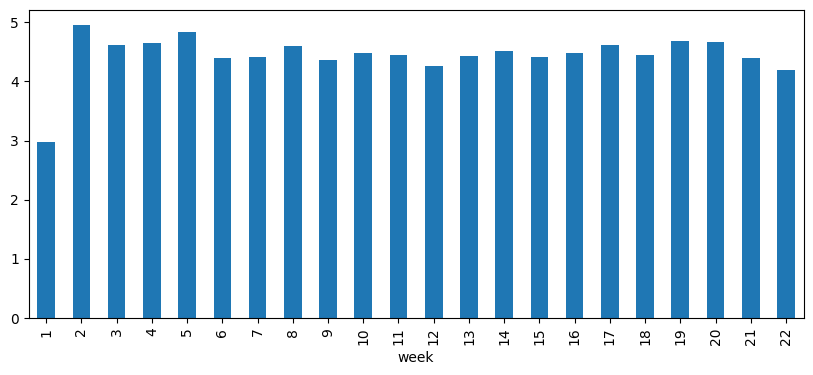

In [26]:
walk_forward_results.groupby("week")["mae"].mean().plot(kind="bar", figsize=(10,4))


In [27]:
import numpy as np

# Get predictions from every individual tree in the forest, not just the averaged final prediction
tree_predictions = np.array([tree.predict(X_test) for tree in rf_model.estimators_])

# Standard deviation across trees for each prediction = model's internal uncertainty
test_rows["tree_variance"] = tree_predictions.std(axis=0)

# Compare: does tree variance correlate with actual error?
test_rows[["tree_variance", "rf_error"]].corr()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

,tree_variance,rf_error
tree_variance,1.000000,0.323884
rf_error,0.323884,1.000000


In [28]:
# Bucket into tiers using quantiles, so each group has a similar number of games
test_rows["tree_variance_tier"] = pd.qcut(
    test_rows["tree_variance"],
    q=3,
    labels=["Low Uncertainty", "Medium Uncertainty", "High Uncertainty"]
)

test_rows.groupby("tree_variance_tier")["rf_error"].agg(["mean", "count"])

/tmp/ipykernel_2829/4135329324.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_rows.groupby("tree_variance_tier")["rf_error"].agg(["mean", "count"])


,mean,count
tree_variance_tier,,
Low Uncertainty,2.982537,1140
Medium Uncertainty,4.420424,1138
High Uncertainty,6.113870,1140


In [29]:
prediction_results.sort_values("rf_error").head(20)

,receiver_player_name,season,week,posteam,defteam,target,reception,receiving_yards,receiving_td,ppr_points,baseline_projection,rf_projection,baseline_error,rf_error
7255,H.Henry,2024,8,NE,NYJ,6,5.0,45.0,0.0,9.5,9.185714,9.495874,0.314286,0.004126
5618,D.Schultz,2024,4,HOU,JAX,5,3.0,34.0,0.0,6.4,3.933333,6.407109,2.466667,0.007109
13242,Mi.Wilson,2024,6,ARI,GB,4,2.0,21.0,1.0,10.1,9.320000,10.088066,0.780000,0.011934
4338,D.Goedert,2024,4,PHI,TB,8,7.0,62.0,0.0,13.2,13.633333,13.216030,0.433333,0.016030
9615,J.Reed,2024,5,GB,LA,6,4.0,78.0,0.0,11.8,15.650000,11.782118,3.850000,0.017882
11489,K.Walker,2024,9,SEA,LA,3,3.0,24.0,0.0,5.4,8.716667,5.382076,3.316667,0.017924
1731,B.Oliver,2024,11,TEN,MIN,1,1.0,33.0,0.0,4.3,4.300000,4.319329,0.000000,0.019329
17962,Z.Charbonnet,2024,17,SEA,CHI,3,3.0,19.0,0.0,4.9,5.164286,4.876984,0.264286,0.023016
2821,C.Kupp,2024,20,LA,PHI,7,5.0,61.0,0.0,11.1,13.684615,11.076107,2.584615,0.023893
1515,B.Bowers,2024,17,LV,NO,7,7.0,77.0,0.0,14.7,15.846667,14.675147,1.146667,0.024853


In [30]:
prediction_results.sort_values("rf_error", ascending=False).head(20)

,receiver_player_name,season,week,posteam,defteam,target,reception,receiving_yards,receiving_td,ppr_points,baseline_projection,rf_projection,baseline_error,rf_error
8779,J.Jennings,2024,3,SF,LA,12,11.0,175.0,3.0,46.5,8.550000,7.978181,37.950000,38.521819
7934,J.Chase,2024,10,CIN,BAL,17,11.0,264.0,3.0,55.4,19.411111,17.706764,35.988889,37.693236
9865,J.Smith-Njigba,2024,9,SEA,LA,13,7.0,180.0,3.0,43.0,11.175000,10.795810,31.825000,32.204190
7929,J.Chase,2024,5,CIN,BAL,12,10.0,193.0,2.0,41.3,16.750000,10.537206,24.550000,30.762794
7654,J.Addison,2024,14,MIN,ATL,12,8.0,133.0,3.0,39.3,11.750000,10.225185,27.550000,29.074815
4845,D.London,2024,18,ATL,CAR,18,10.0,187.0,2.0,40.7,15.025000,12.774263,25.675000,27.925737
1159,A.St. Brown,2024,15,DET,BUF,18,14.0,214.0,1.0,41.4,17.707692,13.930129,23.692308,27.469871
11715,L.McConkey,2024,19,LAC,HOU,14,9.0,197.0,2.0,40.7,14.981250,13.782895,25.718750,26.917105
1155,A.St. Brown,2024,11,DET,JAX,11,11.0,170.0,2.0,40.0,17.377778,13.292376,22.622222,26.707624
8844,J.Jeudy,2024,13,CLE,DEN,14,9.0,237.0,1.0,38.7,11.063636,12.030432,27.636364,26.669568


In [31]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
10,last_8_targets,0.181691
11,last_8_ppr,0.121866
12,last_8_target_share,0.065525
17,season_avg_yards,0.062036
15,season_avg_targets,0.046790
18,season_avg_ppr,0.040491
13,last_5_adot,0.038876
4,last_3_ppr_std,0.037137
9,last_5_target_share,0.034152
14,last_5_red_zone_share,0.032858


In [32]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance[feature_importance["feature"].isin(["last_5_adot", "last_5_red_zone_share"])]

,feature,importance
13,last_5_adot,0.038876
14,last_5_red_zone_share,0.032858


In [33]:
def search_player(name, data=model_data):
    matches = (
        data[data["receiver_player_name"].str.contains(name, case=False, na=False)]
        ["receiver_player_name"]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    if len(matches) == 0:
        print("No matches found.")
    else:
        print(matches)

    return matches

search_player("Metcalf")

['D.Metcalf']


['D.Metcalf']

In [34]:
def get_latest_player_row(player_name, data=model_data):
    # First try exact match
    exact_matches = data[
        data["receiver_player_name"].str.lower() == player_name.lower()
    ].copy()

    if not exact_matches.empty:
        return exact_matches.sort_values(["season", "week"]).iloc[-1]

    # Then try partial match
    partial_matches = data[
        data["receiver_player_name"].str.contains(player_name, case=False, na=False)
    ].copy()

    if partial_matches.empty:
        return None

    # If multiple players match, use the one with most games in data
    best_match_name = (
        partial_matches["receiver_player_name"]
        .value_counts()
        .idxmax()
    )

    best_matches = data[
        data["receiver_player_name"] == best_match_name
    ].copy()

    return best_matches.sort_values(["season", "week"]).iloc[-1]

In [35]:
def get_risk_label(volatility):
    if volatility < 4:
        return "Low Risk"
    elif volatility < 8:
        return "Medium Risk"
    else:
        return "High Risk"

In [36]:
test_rows["risk_label"] = test_rows["last_3_ppr_std"].apply(get_risk_label)

test_rows.groupby("risk_label")["rf_error"].agg(["mean", "count"])

,mean,count
risk_label,,
High Risk,5.796709,523
Low Risk,3.826361,1782
Medium Risk,4.986606,1113


In [37]:
def get_confidence_label(point_difference):
    if point_difference < 1:
        return "Low"
    elif point_difference < 3:
        return "Medium"
    else:
        return "High"

In [38]:
def explain_player(row, projection):
    explanations = []

    if row["last_3_targets"] > row["season_avg_targets"]:
        explanations.append("Target volume is trending up recently.")
    elif row["last_3_targets"] < row["season_avg_targets"]:
        explanations.append("Target volume is trending down recently.")
    else:
        explanations.append("Target volume is close to season average.")

    if row["last_3_ppr"] > row["season_avg_ppr"]:
        explanations.append("Recent fantasy production is above season average.")
    elif row["last_3_ppr"] < row["season_avg_ppr"]:
        explanations.append("Recent fantasy production is below season average.")
    else:
        explanations.append("Recent fantasy production is close to season average.")

    if row["last_3_ppr_std"] >= 8:
        explanations.append("This player has been volatile recently.")
    elif row["last_3_ppr_std"] <= 4:
        explanations.append("This player has been relatively consistent recently.")

    return explanations

In [39]:
def compare_players(player_a, player_b, data, model, features):
    a = get_latest_player_row(player_a, data)
    b = get_latest_player_row(player_b, data)

    if a is None:
        return f"Could not find exact player name: {player_a}. Try search_player('{player_a}')"

    if b is None:
        return f"Could not find exact player name: {player_b}. Try search_player('{player_b}')"

    a_X = pd.DataFrame([a[features]], columns=features)
    b_X = pd.DataFrame([b[features]], columns=features)

    a_proj = model.predict(a_X)[0]
    b_proj = model.predict(b_X)[0]

    difference = abs(a_proj - b_proj)
    confidence = get_confidence_label(difference)

    a_risk = get_risk_label(a["last_3_ppr_std"])
    b_risk = get_risk_label(b["last_3_ppr_std"])

    if a_proj > b_proj:
        recommended = player_a
    else:
        recommended = player_b

    result = {
        "recommended_start": recommended,
        "confidence": confidence,
        "point_difference": round(difference, 2),
        "player_a": {
            "name": player_a,
            "team": a["posteam"],
            "last_opponent_in_data": a["defteam"],
            "projection": round(a_proj, 2),
            "last_3_targets": round(a["last_3_targets"], 2),
            "last_3_ppr": round(a["last_3_ppr"], 2),
            "season_avg_ppr": round(a["season_avg_ppr"], 2),
            "risk": a_risk,
            "explanation": explain_player(a, a_proj)
        },
        "player_b": {
            "name": player_b,
            "team": b["posteam"],
            "last_opponent_in_data": b["defteam"],
            "projection": round(b_proj, 2),
            "last_3_targets": round(b["last_3_targets"], 2),
            "last_3_ppr": round(b["last_3_ppr"], 2),
            "season_avg_ppr": round(b["season_avg_ppr"], 2),
            "risk": b_risk,
            "explanation": explain_player(b, b_proj)
        }
    }

    return result

In [40]:
search_player("Lamb")
search_player("Amon")
compare_players("C.Lamb", "A.St. Brown", model_data, rf_model, features)

['C.Lamb']
No matches found.


{'recommended_start': 'A.St. Brown',
 'confidence': 'High',
 'point_difference': np.float64(3.94),
 'player_a': {'name': 'C.Lamb',
  'team': 'DAL',
  'last_opponent_in_data': 'TB',
  'projection': np.float64(14.49),
  'last_3_targets': np.float64(8.67),
  'last_3_ppr': np.float64(17.93),
  'season_avg_ppr': np.float64(17.08),
  'risk': 'High Risk',
  'explanation': ['Target volume is trending down recently.',
   'Recent fantasy production is above season average.',
   'This player has been volatile recently.']},
 'player_b': {'name': 'A.St. Brown',
  'team': 'DET',
  'last_opponent_in_data': 'WAS',
  'projection': np.float64(18.43),
  'last_3_targets': np.float64(8.33),
  'last_3_ppr': np.float64(20.93),
  'season_avg_ppr': np.float64(19.67),
  'risk': 'High Risk',
  'explanation': ['Target volume is trending up recently.',
   'Recent fantasy production is above season average.',
   'This player has been volatile recently.']}}

In [41]:
def pretty_compare(player_a, player_b):
    result = compare_players(player_a, player_b, model_data, rf_model, features)

    if isinstance(result, str):
        print(result)
        return

    print("GRIDEDGE START/SIT RESULT")
    print("-" * 40)
    print("Recommended Start:", result["recommended_start"])
    print("Confidence:", result["confidence"])
    print("Projected Difference:", result["point_difference"])
    print()

    for key in ["player_a", "player_b"]:
        p = result[key]
        print(p["name"])
        print("Projection:", p["projection"], "PPR points")
        print("Team:", p["team"])
        print("Risk:", p["risk"])
        print("Last 3 Targets:", p["last_3_targets"])
        print("Last 3 PPR:", p["last_3_ppr"])
        print("Season Avg PPR:", p["season_avg_ppr"])
        print("Why:")
        for reason in p["explanation"]:
            print("-", reason)
        print()

In [42]:
search_player("Godwin")
search_player("Samuel")
pretty_compare("C.Godwin", "D.Samuel")

['C.Godwin']
['C.Samuel', 'D.Samuel']
GRIDEDGE START/SIT RESULT
----------------------------------------
Recommended Start: C.Godwin
Confidence: High
Projected Difference: 4.78

C.Godwin
Projection: 16.78 PPR points
Team: TB
Risk: High Risk
Last 3 Targets: 9.33
Last 3 PPR: 20.23
Season Avg PPR: 20.83
Why:
- Target volume is trending up recently.
- Recent fantasy production is below season average.
- This player has been volatile recently.

D.Samuel
Projection: 12.0 PPR points
Team: SF
Risk: High Risk
Last 3 Targets: 6.33
Last 3 PPR: 10.47
Season Avg PPR: 9.88
Why:
- Target volume is trending up recently.
- Recent fantasy production is above season average.
- This player has been volatile recently.



In [43]:
model_data.to_csv("wr_model_data_2023.csv", index=False)
prediction_results.to_csv("wr_prediction_results_2023.csv", index=False)

print("Files saved")

Files saved


In [44]:
## from google.colab import files

## files.download("wr_model_data_2023.csv")
## files.download("wr_prediction_results_2023.csv")

In [45]:
import pickle

# Save the trained model
with open('gridedge_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the processed data the app will need to look up players
model_data.to_csv('gridedge_data.csv', index=False)

print("Saved model and data files")

Saved model and data files


In [46]:
import joblib

joblib.dump(rf_model, 'gridedge_model_compressed.pkl', compress=3)

['gridedge_model_compressed.pkl']

In [47]:
context_features = [
    "def_allowed_ppr_last_5",
    "def_allowed_targets_last_5",
    "def_allowed_yards_last_5",
    "def_allowed_tds_last_5",
    "week",
    "last_3_ppr_std"
]

error_correlations = test_rows[context_features + ["rf_error"]].corr()["rf_error"].drop("rf_error")
error_correlations.sort_values(ascending=False)

,rf_error
last_3_ppr_std,0.184151
def_allowed_ppr_last_5,0.048306
def_allowed_tds_last_5,0.048050
def_allowed_yards_last_5,0.033601
def_allowed_targets_last_5,0.032946
week,-0.002177


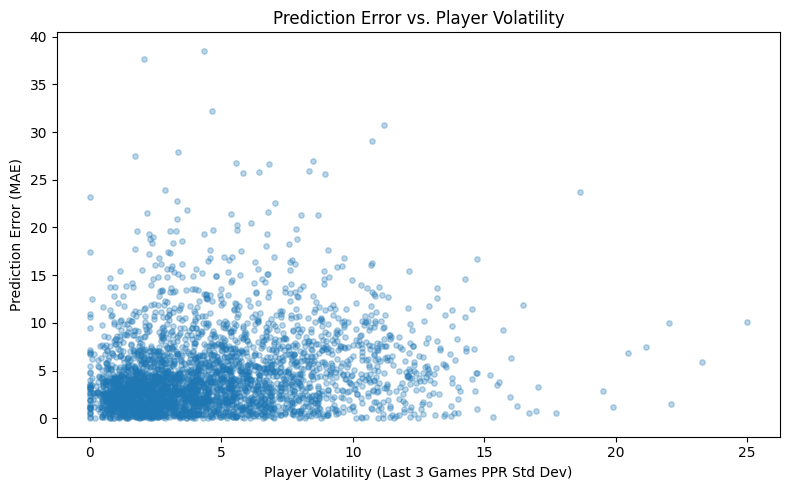

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(test_rows["last_3_ppr_std"], test_rows["rf_error"], alpha=0.3, s=15)
plt.xlabel("Player Volatility (Last 3 Games PPR Std Dev)")
plt.ylabel("Prediction Error (MAE)")
plt.title("Prediction Error vs. Player Volatility")
plt.tight_layout()
plt.show()

In [49]:
!pip install shap -q

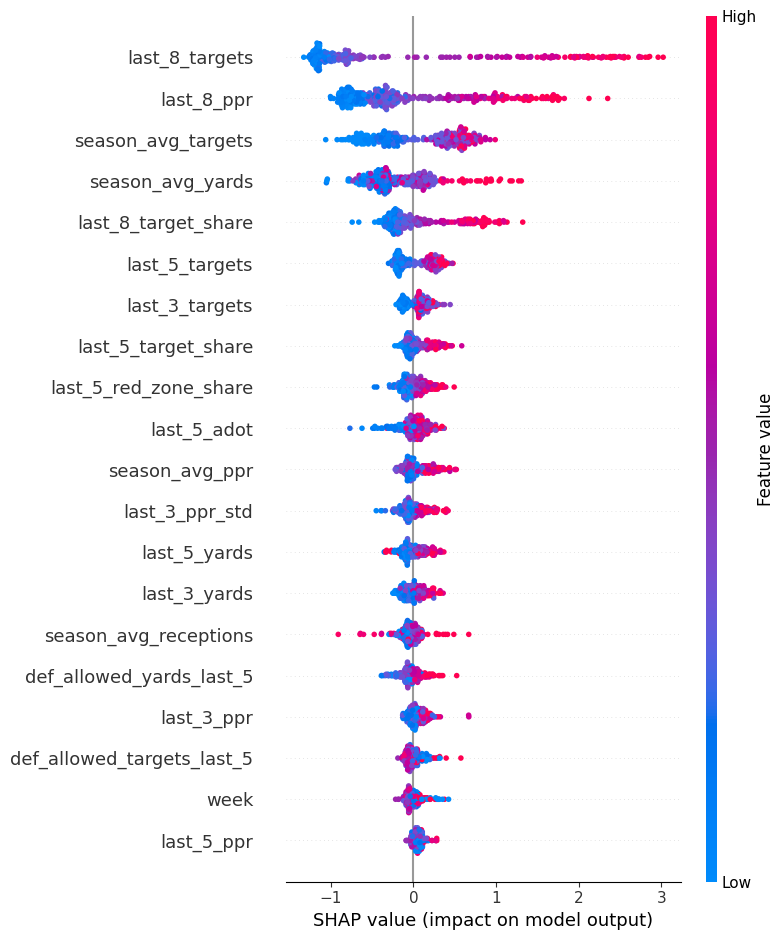

In [50]:
import shap

X_test_sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

shap.summary_plot(shap_values, X_test_sample, feature_names=features)